Code for Subsection 3.1. Posterior Sampling for Penalized Logistic Regression.

(a) Convergence error under $N(0,I_d)$, h=5.00e-04, TUSLA RMSE=1.6350e-01, tSGHMC RMSE=1.2833e-02
(a) Convergence error under $N(0,I_d)$, h=7.00e-04, TUSLA RMSE=2.1466e-01, tSGHMC RMSE=1.5728e-02
(a) Convergence error under $N(0,I_d)$, h=1.00e-03, TUSLA RMSE=2.4917e-01, tSGHMC RMSE=1.9820e-02
(a) Convergence error under $N(0,I_d)$, h=1.40e-03, TUSLA RMSE=3.0902e-01, tSGHMC RMSE=2.3090e-02
(a) Convergence error under $N(0,I_d)$, h=1.90e-03, TUSLA RMSE=3.5275e-01, tSGHMC RMSE=2.7698e-02
(a) Convergence error under $N(0,I_d)$, h=2.70e-03, TUSLA RMSE=4.0353e-01, tSGHMC RMSE=3.3014e-02
(a) Convergence error under $N(0,I_d)$, h=3.70e-03, TUSLA RMSE=4.5558e-01, tSGHMC RMSE=3.9752e-02
(a) Convergence error under $N(0,I_d)$, h=5.00e-03, TUSLA RMSE=4.9382e-01, tSGHMC RMSE=4.3068e-02
(a) Convergence error under $N(0,I_d)$: slope TUSLA  = 0.4727
(a) Convergence error under $N(0,I_d)$: slope tSGHMC = 0.5352
(b) Convergence error under $N(0,4I_d)$, h=5.00e-04, TUSLA RMSE=2.6251e-01, tSGHMC RMSE=2.44

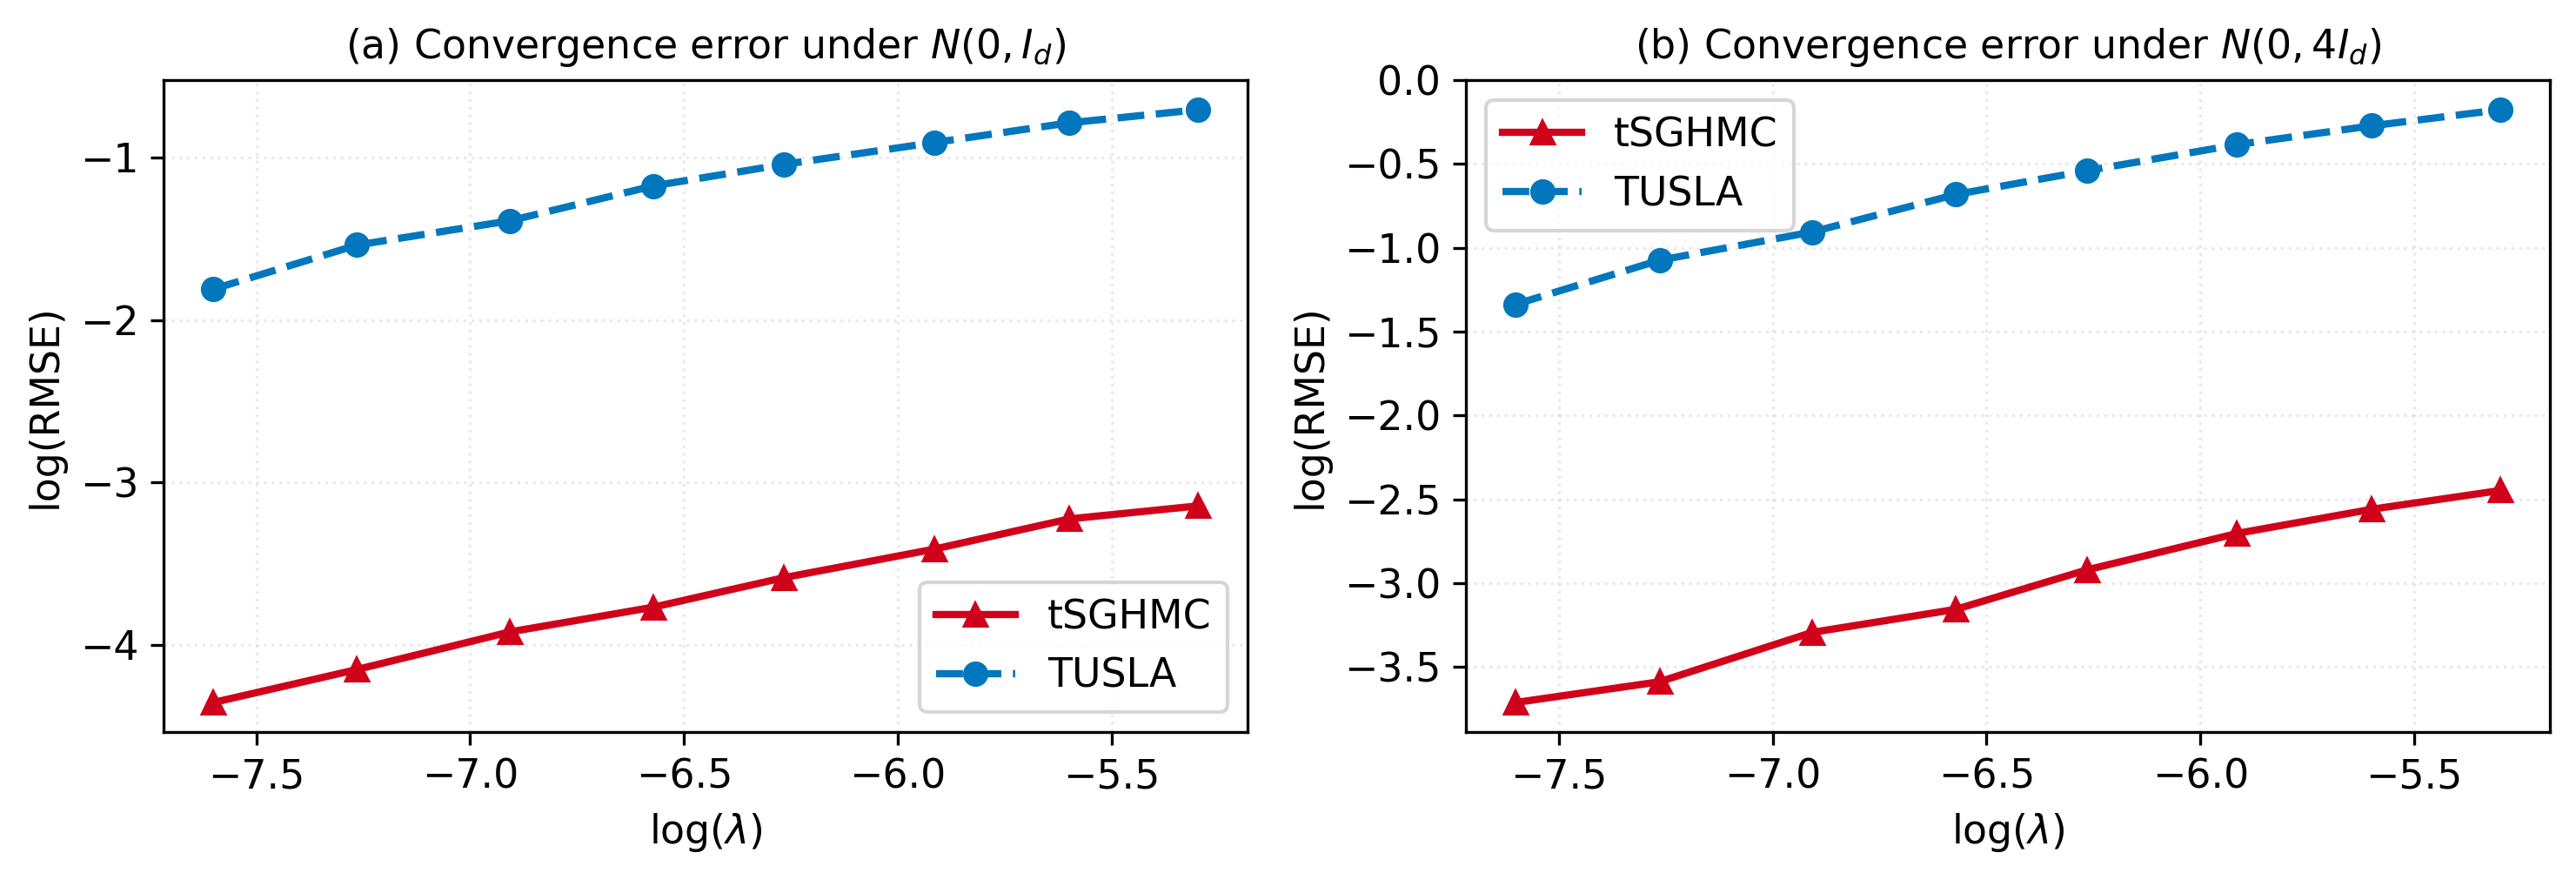

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def make_data(n=100, d=3, x_std=1.0, seed=123):
    rng = np.random.default_rng(seed)
    X = rng.normal(0.0, x_std, size=(n, d))
    theta_star = rng.normal(0.0, 1.0, size=d)
    p = 1.0 / (1.0 + np.exp(-(X @ theta_star)))
    y = 2 * rng.binomial(1, p, size=n) - 1
    return X, y


def H_logistic(theta, z, eta):
    x, y = z
    s = y * np.dot(x, theta)
    if s >= 0:
        w = np.exp(-s) / (1.0 + np.exp(-s))
    else:
        w = 1.0 / (1.0 + np.exp(s))
    return -y * x * w + eta * theta


def H_tusla(theta, z, h, eta, r):
    return H_logistic(theta, z, eta) / (
        1.0 + np.sqrt(h) * np.linalg.norm(theta) ** (2.0 * r)
    )


def H_tsghmc(theta, z, eta, m, gamma, r):
    H = H_logistic(theta, z, eta)
    f = H - m * theta
    return m * theta + f / np.sqrt(
        1.0 + np.linalg.norm(theta) ** (4.0 * r) / gamma
    )


def run_tusla_coupled(X, y, theta0, h, beta, eta, r, idx_fine, xi_fine, h_ref):
    q = int(round(h / h_ref))
    N = len(idx_fine) // q
    theta = theta0.copy()

    for k in range(N):
        start, end = k * q, (k + 1) * q
        xi_c = np.sum(xi_fine[start:end], axis=0) / np.sqrt(q)
        idx_c = idx_fine[end - 1]
        z = (X[idx_c], y[idx_c])

        theta = theta - h * H_tusla(theta, z, h, eta, r) + np.sqrt(2.0 * h / beta) * xi_c

    return theta


def run_tsghmc_coupled(X, y, theta0, v0, h, gamma, beta, eta, m, r,
                       idx_fine, xi_fine, h_ref):
    q = int(round(h / h_ref))
    N = len(idx_fine) // q
    theta = theta0.copy()
    v = v0.copy()

    for k in range(N):
        start, end = k * q, (k + 1) * q
        xi_c = np.sum(xi_fine[start:end], axis=0) / np.sqrt(q)
        idx_c = idx_fine[end - 1]
        z = (X[idx_c], y[idx_c])

        v = (v - h * (gamma * v + H_tsghmc(theta, z, eta, m, gamma, r)) + np.sqrt(2.0 * h * gamma / beta) * xi_c)
        theta = theta + h * v

    return theta


def rmse(samples, ref_samples):
    return np.sqrt(np.mean(np.sum((samples - ref_samples) ** 2, axis=1)))


def run_experiment(x_std, label, params):
    n_data = params["n_data"]
    d = params["d"]
    eta = params["eta"]
    beta = params["beta"]
    gamma = params["gamma"]
    m = params["m"]
    r = params["r"]
    T = params["T"]
    R = params["R"]
    h_ref = params["h_ref"]
    q_list = params["q_list"]
    step_sizes = q_list * h_ref
    N_ref = int(round(T / h_ref))

    X, y = make_data(n=n_data, d=d, x_std=x_std, seed=123)

    rng_init = np.random.default_rng(999)
    theta0_list = rng_init.normal(0.0, 1.0, size=(R, d))
    v0_list = np.zeros((R, d))

    rmse_tusla = []
    rmse_tsghmc = []

    for h in step_sizes:
        q = int(round(h / h_ref))
        if abs(h - q * h_ref) > 1e-14:
            raise ValueError("Each h must be an integer multiple of h_ref.")

        ref_tusla = np.zeros((R, d))
        ref_tsghmc = np.zeros((R, d))
        samp_tusla = np.zeros((R, d))
        samp_tsghmc = np.zeros((R, d))

        for i in range(R):
            rng = np.random.default_rng(10000 + i)

            idx_fine = rng.integers(0, n_data, size=N_ref)
            xi_fine_tusla = rng.normal(0.0, 1.0, size=(N_ref, d))
            xi_fine_tsghmc = rng.normal(0.0, 1.0, size=(N_ref, d))

            theta0 = theta0_list[i]
            v0 = v0_list[i]

            ref_tusla[i] = run_tusla_coupled(X, y, theta0, h_ref, beta, eta, r, idx_fine, xi_fine_tusla, h_ref)
            samp_tusla[i] = run_tusla_coupled(X, y, theta0, h, beta, eta, r, idx_fine, xi_fine_tusla, h_ref)

            ref_tsghmc[i] = run_tsghmc_coupled(X, y, theta0, v0, h_ref, gamma, beta, eta, m, r, idx_fine, xi_fine_tsghmc, h_ref)
            samp_tsghmc[i] = run_tsghmc_coupled(X, y, theta0, v0, h, gamma, beta, eta, m, r, idx_fine, xi_fine_tsghmc, h_ref)

        e_tusla = rmse(samp_tusla, ref_tusla)
        e_tsghmc = rmse(samp_tsghmc, ref_tsghmc)

        rmse_tusla.append(e_tusla)
        rmse_tsghmc.append(e_tsghmc)

        print(
            f"{label}, h={h:.2e}, "
            f"TUSLA RMSE={e_tusla:.4e}, "
            f"tSGHMC RMSE={e_tsghmc:.4e}"
        )

    return step_sizes, np.array(rmse_tusla), np.array(rmse_tsghmc)


def main():
    params = {
        "n_data": 100,
        "d": 3,
        "eta": 1e-3,
        "beta": 1.0,
        "gamma": 1.0,
        "r": 1.0,
        "T": 5.0,
        "R": 100,
        "h_ref": 1e-4, # reference step size
        "q_list": np.array([5, 7, 10, 14, 19, 27, 37, 50]), # tested step size: 5e-4 to 5e-3
    }
    params["m"] = params["eta"]

    experiments = [
        (1.0, r"(a) Convergence error under $N(0,I_d)$"),
        (2.0, r"(b) Convergence error under $N(0,4I_d)$"),
    ]

    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.titlesize": 11,
    })

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)

    for ax, (x_std, title) in zip(axes, experiments):
        step_sizes, rmse_tusla, rmse_tsghmc = run_experiment(x_std=x_std, label=title, params=params)

        ax.plot(np.log(step_sizes), np.log(rmse_tsghmc), color='#d0021b', marker='^', linewidth=2.0, markersize=6.0, label='tSGHMC')
        ax.plot(np.log(step_sizes), np.log(rmse_tusla), color='#0277bd', marker='o', linestyle="--", linewidth=2.0, markersize=6.0, label='TUSLA')
        
        ax.set_title(title)
        ax.set_xlabel(r"$\log(\lambda)$")
        ax.set_ylabel("log(RMSE)")
        ax.tick_params(axis="y", labelleft=True)
        ax.grid(alpha=0.25, linestyle=':')
        ax.legend(frameon=True, loc='best')

        slope_tusla = np.polyfit(np.log(step_sizes), np.log(rmse_tusla), 1)[0]
        slope_tsghmc = np.polyfit(np.log(step_sizes), np.log(rmse_tsghmc), 1)[0]
        print(f"{title}: slope TUSLA  = {slope_tusla:.4f}")
        print(f"{title}: slope tSGHMC = {slope_tsghmc:.4f}")

    plt.tight_layout()
    plt.show()

    # fig.savefig('Example1_Sampling.png', dpi=220, bbox_inches='tight')


if __name__ == "__main__":
    main()